# Milestone 3: Complete Implementation — Spotify Audio Features & Song Clusters
**Sarbani Adhikari** | CS 4412

Note: this continues from M2 (analysis_v1.ipynb). Reproduces the preprocessing + K-Means from M2,
then adds DBSCAN, decision trees, and anomaly detection. Figures save to `../outputs/figures/`.
Run from the `notebooks/` folder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

## 1. Data Loading & Preprocessing (from M2)

Reproducing the M2 pipeline so this notebook is self-contained.

In [2]:
df = pd.read_csv('../data/dataset.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)

(114000, 20)


In [3]:
df.dropna(subset=['artists', 'album_name', 'track_name'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"dropped rows with missing metadata, shape: {df.shape}")

dropped rows with missing metadata, shape: (113999, 20)


In [4]:
df = df.drop_duplicates(subset=['track_id'], keep='first').reset_index(drop=True)
print(f"after dedup: {df.shape}")
print(f"genres: {df['track_genre'].nunique()}")

after dedup: (89740, 20)
genres: 113


## 2. Standardization, PCA, K-Means (from M2)

In [5]:
clustering_features = ['danceability', 'energy', 'valence', 'acousticness', 
                       'instrumentalness', 'speechiness', 'liveness', 'loudness', 'tempo']
audioFeatures = ['danceability', 'energy', 'valence', 'acousticness', 
                  'instrumentalness', 'speechiness', 'liveness', 'loudness', 'tempo']

X = df[clustering_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca2d = PCA(n_components=2)
X_pca_all = pca2d.fit_transform(X_scaled)
print(f"PCA: {pca2d.explained_variance_ratio_[0]:.1%} + {pca2d.explained_variance_ratio_[1]:.1%} = {sum(pca2d.explained_variance_ratio_):.1%}")

PCA: 32.1% + 15.9% = 48.0%


In [6]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)
clusterColors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

print(f"silhouette: {silhouette_score(X_scaled, df['cluster'], sample_size=10000, random_state=42):.4f}")
print(df['cluster'].value_counts().sort_index())

silhouette: 0.1774
cluster
0    26856
1    20830
2    33656
3     7296
4     1102
Name: count, dtype: int64


same results as M2. 5 clusters, silhouette around 0.18. now onto the new stuff.

## 3. DBSCAN Clustering

DBSCAN doesn't need you to pick k ahead of time, and it can find noise points (outliers). Running on a 20k sample because DBSCAN with ~90k rows in 9 dimensions is really slow.

### parameter search

trying a few eps / min_samples combos to see what works.

In [7]:
np.random.seed(42)
dbscan_idx = np.random.choice(len(X_scaled), size=20000, replace=False)
X_dbscan = X_scaled[dbscan_idx]

results = []
for eps_val in [1.5, 2.0, 2.5, 3.0]:
    for ms in [10, 15, 20]:
        db = DBSCAN(eps=eps_val, min_samples=ms)
        labels = db.fit_predict(X_dbscan)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        results.append({'eps': eps_val, 'min_samples': ms, 'clusters': n_clusters, 
                       'noise': n_noise, 'noise_pct': round(n_noise/len(X_dbscan)*100, 1)})
        print(f"eps={eps_val}, min_samples={ms}: {n_clusters} clusters, {n_noise} noise ({n_noise/len(X_dbscan)*100:.1f}%)")

eps=1.5, min_samples=10: 3 clusters, 469 noise (2.3%)
eps=1.5, min_samples=15: 2 clusters, 578 noise (2.9%)
eps=1.5, min_samples=20: 2 clusters, 647 noise (3.2%)
eps=2.0, min_samples=10: 2 clusters, 127 noise (0.6%)
eps=2.0, min_samples=15: 3 clusters, 144 noise (0.7%)
eps=2.0, min_samples=20: 2 clusters, 181 noise (0.9%)
eps=2.5, min_samples=10: 1 clusters, 37 noise (0.2%)
eps=2.5, min_samples=15: 1 clusters, 42 noise (0.2%)
eps=2.5, min_samples=20: 1 clusters, 46 noise (0.2%)
eps=3.0, min_samples=10: 1 clusters, 5 noise (0.0%)
eps=3.0, min_samples=15: 1 clusters, 8 noise (0.0%)
eps=3.0, min_samples=20: 1 clusters, 20 noise (0.1%)


eps=2.5+ collapses everything into 1 cluster. eps=1.5 gives 2 clusters with ~3% noise. eps=2.0 gives 3 clusters with less noise. going with eps=2.0, min_samples=15 as a middle ground -- enough structure but not too noisy.

In [8]:
dbscan = DBSCAN(eps=2.0, min_samples=15)
db_labels = dbscan.fit_predict(X_dbscan)
df_dbscan = df.iloc[dbscan_idx].copy()
df_dbscan['dbscan_label'] = db_labels

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f"DBSCAN found {n_db_clusters} clusters and {n_noise} noise points ({n_noise/len(db_labels)*100:.1f}%)")
print(pd.Series(db_labels).value_counts().sort_index())

DBSCAN found 3 clusters and 144 noise points (0.7%)
-1      144
 0    19677
 1      154
 2       25
Name: count, dtype: int64


3 clusters but very uneven -- one massive cluster (19k+), one small one (~150), and a tiny one (~25). plus ~144 noise points. DBSCAN is seeing the data as mostly one big dense blob with a couple small offshoots.

### DBSCAN vs K-Means

In [9]:
km_labels_sample = df['cluster'].values[dbscan_idx]

ct = pd.crosstab(pd.Series(km_labels_sample, name='KMeans'), 
                 pd.Series(db_labels, name='DBSCAN'))
print(ct)

DBSCAN  -1     0    1   2
KMeans                   
0       10  5909    0   5
1       10  4642    0   0
2        1  7590    0   0
3       86  1494    0  20
4       37    42  154   0


K-Means cluster 4 (the hip-hop/speech cluster) maps almost perfectly to DBSCAN cluster 1. the rest all get lumped into DBSCAN cluster 0. this makes sense -- most audio features form one big continuous distribution, and only the high-speechiness tracks are truly separated by density. K-Means forces 5 groups even where there's no real density gap.

### silhouette comparison

In [10]:
km_sil = silhouette_score(X_scaled, df['cluster'], sample_size=10000, random_state=42)
print(f"K-Means (k=5): {km_sil:.4f}")

non_noise = db_labels != -1
if len(set(db_labels[non_noise])) > 1:
    db_sil = silhouette_score(X_dbscan[non_noise], db_labels[non_noise], 
                              sample_size=min(10000, non_noise.sum()), random_state=42)
    print(f"DBSCAN (excl noise): {db_sil:.4f}")

# K-Means on same sample for fair comparison
km_sample_sil = silhouette_score(X_dbscan, df['cluster'].values[dbscan_idx], 
                                  sample_size=10000, random_state=42)
print(f"K-Means (same 20k sample): {km_sample_sil:.4f}")

K-Means (k=5): 0.1774
DBSCAN (excl noise): 0.4145
K-Means (same 20k sample): 0.1789


DBSCAN's silhouette (0.41) looks way better than K-Means (0.18) but that's misleading. DBSCAN puts 98.5% of tracks into one cluster and only separates out tiny pockets, so of course those pockets are well-separated. K-Means actually tries to divide the whole space into 5 groups, which is harder. the silhouette scores aren't really comparable here because the methods are answering different questions.

### silhouette comparison

In [11]:
km_sil = silhouette_score(X_scaled, df['cluster'], sample_size=10000, random_state=42)
print(f"K-Means (k=5): {km_sil:.4f}")

non_noise = db_labels != -1
if len(set(db_labels[non_noise])) > 1:
    db_sil = silhouette_score(X_dbscan[non_noise], db_labels[non_noise], 
                               sample_size=min(10000, non_noise.sum()), random_state=42)
    print(f"DBSCAN (eps=2.0, excl noise): {db_sil:.4f}")
    print(f"  ({non_noise.sum()} of {len(db_labels)} points, {len(set(db_labels[non_noise]))} clusters)")

K-Means (k=5): 0.1774
DBSCAN (eps=2.0, excl noise): 0.4145
  (19856 of 20000 points, 3 clusters)


DBSCAN's silhouette (0.41) is way higher than K-Means (0.18), but this is misleading. DBSCAN puts 98.5% of points in one cluster and only separates the most obvious outliers, so of course those well-separated pockets have high silhouette. K-Means is doing the harder job of splitting a continuous blob into 5 groups, which naturally produces more boundary overlap. higher silhouette doesn't mean DBSCAN is "better" here -- they're answering different questions.

### visualizing DBSCAN in PCA space

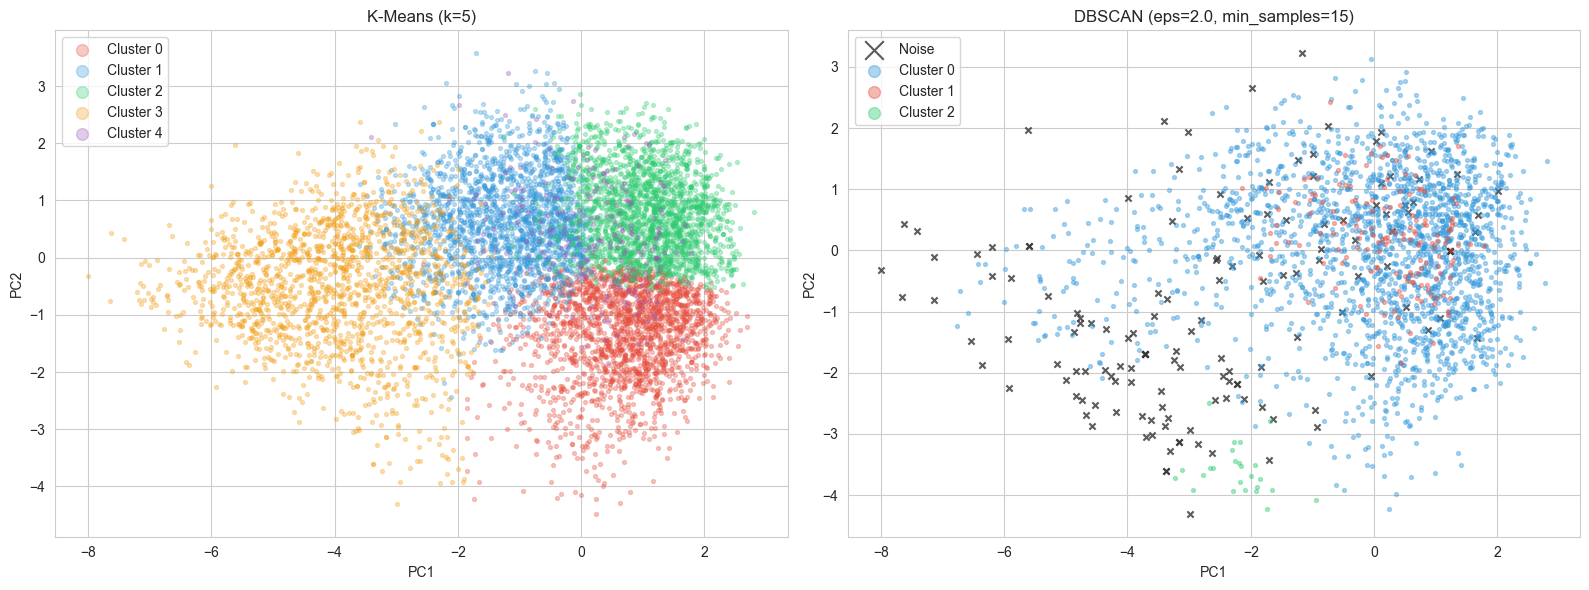

In [12]:
X_pca_dbscan = X_pca_all[dbscan_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# left: K-Means on same sample
for i in range(5):
    mask = km_labels_sample == i
    idx = np.where(mask)[0]
    if len(idx) > 2000:
        idx = np.random.choice(idx, 2000, replace=False)
    axes[0].scatter(X_pca_dbscan[idx, 0], X_pca_dbscan[idx, 1], 
                   c=clusterColors[i], alpha=0.3, s=8, label=f'Cluster {i}')
axes[0].set_title('K-Means (k=5)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3)

# right: DBSCAN
dbColors = {-1: '#333333', 0: '#3498db', 1: '#e74c3c', 2: '#2ecc71'}
dbLabels = {-1: 'Noise', 0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}
for lab in sorted(set(db_labels)):
    mask = db_labels == lab
    idx = np.where(mask)[0]
    if len(idx) > 2000:
        idx = np.random.choice(idx, 2000, replace=False)
    axes[1].scatter(X_pca_dbscan[idx, 0], X_pca_dbscan[idx, 1], 
                   c=dbColors.get(lab, '#999999'), alpha=0.4 if lab != -1 else 0.8, 
                   s=8 if lab != -1 else 20, label=dbLabels.get(lab, f'{lab}'),
                   marker='o' if lab != -1 else 'x')
axes[1].set_title('DBSCAN (eps=2.0, min_samples=15)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig('../outputs/figures/fig15_dbscan_vs_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

the noise points (black X's) sit on the edges of the distribution. DBSCAN's main cluster basically covers everything K-Means splits into 4 groups.

### what are the noise points?

In [13]:
noise_df = df_dbscan[df_dbscan['dbscan_label'] == -1]
print(f"{len(noise_df)} noise points")
print(f"\ntop genres in noise:")
print(noise_df['track_genre'].value_counts().head(10))

144 noise points

top genres in noise:
track_genre
sleep          65
comedy         10
iranian        10
study           7
world-music     5
jazz            5
show-tunes      4
funk            3
classical       3
children        3
Name: count, dtype: int64


In [14]:
print("\nsome noise tracks:")
for _, row in noise_df.sample(8, random_state=42).iterrows():
    print(f"  {row['track_name']} by {row['artists']} ({row['track_genre']})")
    print(f"    dance={row['danceability']:.2f} energy={row['energy']:.2f} acoustic={row['acousticness']:.2f} speech={row['speechiness']:.2f} inst={row['instrumentalness']:.2f} loud={row['loudness']:.1f}dB")


some noise tracks:
  White Noise (Loopable, No Fade) by Rain Sounds;Sleep Sounds of Nature (sleep)
    dance=0.00 energy=0.00 acoustic=0.36 speech=0.00 inst=0.90 loud=-29.6dB
  Pink Noise For Sleep 1 by Granular (sleep)
    dance=0.00 energy=0.01 acoustic=0.93 speech=0.00 inst=0.48 loud=-22.0dB
  Waves: White Noise Sleep by Ocean Waves For Sleep (sleep)
    dance=0.06 energy=0.29 acoustic=0.00 speech=0.26 inst=0.00 loud=-17.2dB
  What's the Time, Mr Wolf? by The Wiggles (children)
    dance=0.67 energy=0.40 acoustic=0.22 speech=0.81 inst=0.00 loud=-11.0dB
  Soothing Massage Rain by Nature Sounds (sleep)
    dance=0.08 energy=0.00 acoustic=0.00 speech=0.27 inst=0.57 loud=-23.3dB
  Salmon Benedict by Timothy Infinite (study)
    dance=0.72 energy=0.43 acoustic=0.93 speech=0.37 inst=0.80 loud=-11.1dB
  Down Down Baby by The Laurie Berkner Band (children)
    dance=0.71 energy=0.50 acoustic=0.83 speech=0.88 inst=0.00 loud=-11.4dB
  N Word by Chris Robinson (comedy)
    dance=0.60 energy=0

sleep, comedy, and iranian music dominate the noise points. these are genres with unusual audio profiles -- sleep tracks are extremely quiet and instrumental, comedy is basically spoken word, and iranian music has different tonal structures. makes sense that they'd be density outliers.

### what's in DBSCAN clusters 1 and 2?

they look like they overlap with cluster 0 in PCA space, but DBSCAN runs in the full 9D space. let's see what actually separates them.

In [15]:
for lab in sorted(set(db_labels)):
    mask = db_labels == lab
    n = mask.sum()
    name = "Noise" if lab == -1 else f"Cluster {lab}"
    means = df_dbscan[mask][clustering_features].mean()
    top_g = df_dbscan[mask]['track_genre'].value_counts().head(4).index.tolist()
    print(f"\n{name} (n={n}):")
    print(f"  dance={means['danceability']:.2f} energy={means['energy']:.2f} valence={means['valence']:.2f} acoustic={means['acousticness']:.2f}")
    print(f"  inst={means['instrumentalness']:.2f} speech={means['speechiness']:.2f} live={means['liveness']:.2f} loud={means['loudness']:.1f}dB tempo={means['tempo']:.0f}")
    print(f"  genres: {', '.join(top_g)}")


Noise (n=144):
  dance=0.30 energy=0.41 valence=0.25 acoustic=0.57
  inst=0.48 speech=0.27 live=0.52 loud=-19.0dB tempo=82
  genres: sleep, comedy, iranian, study

Cluster 0 (n=19677):
  dance=0.56 energy=0.63 valence=0.47 acoustic=0.32
  inst=0.17 speech=0.08 live=0.21 loud=-8.4dB tempo=123
  genres: forro, heavy-metal, club, bluegrass

Cluster 1 (n=154):
  dance=0.56 energy=0.73 valence=0.41 acoustic=0.80
  inst=0.00 speech=0.90 live=0.78 loud=-10.9dB tempo=96
  genres: comedy, afrobeat, classical, children

Cluster 2 (n=25):
  dance=0.18 energy=0.98 valence=0.01 acoustic=0.36
  inst=0.92 speech=0.06 live=0.88 loud=-20.7dB tempo=95
  genres: sleep, world-music


cluster 1 is the spoken-word/live performance pocket: speechiness=0.90 and liveness=0.78, mostly comedy tracks. cluster 2 is a tiny group of extreme tracks with near-max energy (0.98) but near-zero valence (0.005) and high instrumentalness (0.92) -- probably droning noise or field recordings from sleep/world-music. these clusters overlap with cluster 0 in PCA space because their distinguishing features (speechiness, liveness) aren't well captured by PC1 and PC2. in the full 9D space they're dense enough to form their own pockets.

### what's in DBSCAN clusters 1 and 2?

they overlap with cluster 0 in PCA space, so let's see if they're actually different in the full 9D feature space.

In [16]:
for lab in sorted(df_dbscan['dbscan_label'].unique()):
    subset = df_dbscan[df_dbscan['dbscan_label'] == lab]
    name = f"Cluster {lab}" if lab != -1 else "Noise"
    print(f"\n--- {name} (n={len(subset)}) ---")
    for feat in clustering_features:
        print(f"  {feat}: {subset[feat].mean():.3f}")
    print(f"  top genres: {', '.join(subset['track_genre'].value_counts().head(4).index.tolist())}")


--- Noise (n=144) ---
  danceability: 0.299
  energy: 0.407
  valence: 0.246
  acousticness: 0.566
  instrumentalness: 0.481
  speechiness: 0.266
  liveness: 0.518
  loudness: -19.044
  tempo: 81.943
  top genres: sleep, comedy, iranian, study

--- Cluster 0 (n=19677) ---
  danceability: 0.565
  energy: 0.634
  valence: 0.474
  acousticness: 0.323
  instrumentalness: 0.170
  speechiness: 0.079
  liveness: 0.208
  loudness: -8.371
  tempo: 122.540
  top genres: forro, heavy-metal, club, bluegrass

--- Cluster 1 (n=154) ---
  danceability: 0.564
  energy: 0.732
  valence: 0.410
  acousticness: 0.805
  instrumentalness: 0.000
  speechiness: 0.902
  liveness: 0.777
  loudness: -10.932
  tempo: 95.654
  top genres: comedy, afrobeat, classical, children

--- Cluster 2 (n=25) ---
  danceability: 0.183
  energy: 0.978
  valence: 0.005
  acousticness: 0.360
  instrumentalness: 0.918
  speechiness: 0.056
  liveness: 0.882
  loudness: -20.696
  tempo: 94.813
  top genres: sleep, world-music


cluster 1 (154 tracks) has extremely high speechiness (0.90) and liveness (0.78) with zero instrumentalness -- these are live spoken-word performances, mostly comedy. cluster 2 (25 tracks) is the opposite extreme: near-max energy (0.98), near-zero valence (0.005), high instrumentalness (0.92), and high liveness (0.88) but very quiet (-20.7 dB). these are intense, dark, instrumental live recordings -- a really unusual combination.

they look overlapped in PCA space because PCA only captures ~48% of the variance. the features that separate them (speechiness, liveness, instrumentalness) load more on PC3+ which we're not showing. in 9D they're genuinely in different neighborhoods.

## 4. Decision Tree on Cluster Labels

Using the K-Means cluster assignments as the target variable. The goal isn't prediction accuracy -- it's to get interpretable rules for what defines each cluster.

In [17]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_scaled, df['cluster'])

print(f"training accuracy: {dt.score(X_scaled, df['cluster']):.4f}")
print("\n(this is high but we're not trying to generalize -- we want the rules)")

training accuracy: 0.8470

(this is high but we're not trying to generalize -- we want the rules)


### feature importances

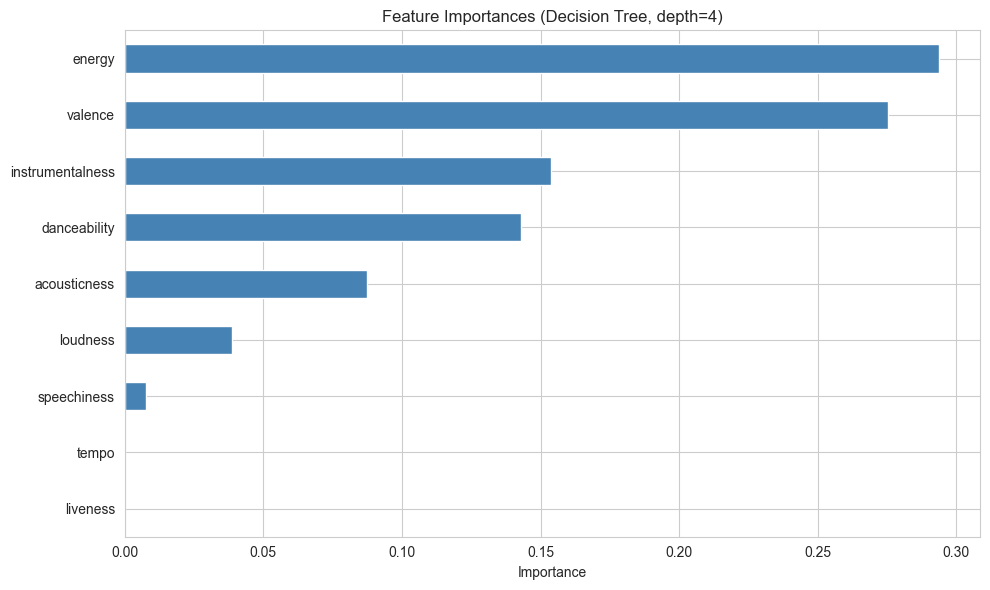

top features:
  energy: 0.294
  valence: 0.275
  instrumentalness: 0.154
  danceability: 0.143
  acousticness: 0.087
  loudness: 0.039


In [18]:
importances = pd.Series(dt.feature_importances_, index=clustering_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances (Decision Tree, depth=4)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/figures/fig16_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print("top features:")
for feat, imp in importances.sort_values(ascending=False).items():
    if imp > 0.01:
        print(f"  {feat}: {imp:.3f}")

energy and valence are the most important splits, followed by instrumentalness and danceability. tempo and liveness basically don't matter for distinguishing clusters. this lines up with PCA where PC1 was mostly energy/acousticness and PC2 was valence/danceability.

### tree rules

In [19]:
print(export_text(dt, feature_names=clustering_features, max_depth=3))

|--- energy <= -0.32
|   |--- instrumentalness <= 1.09
|   |   |--- acousticness <= 0.02
|   |   |   |--- danceability <= 0.31
|   |   |   |   |--- class: 1
|   |   |   |--- danceability >  0.31
|   |   |   |   |--- class: 2
|   |   |--- acousticness >  0.02
|   |   |   |--- loudness <= -2.05
|   |   |   |   |--- class: 3
|   |   |   |--- loudness >  -2.05
|   |   |   |   |--- class: 1
|   |--- instrumentalness >  1.09
|   |   |--- loudness <= -0.89
|   |   |   |--- danceability <= 0.87
|   |   |   |   |--- class: 3
|   |   |   |--- danceability >  0.87
|   |   |   |   |--- class: 3
|   |   |--- loudness >  -0.89
|   |   |   |--- acousticness <= -0.33
|   |   |   |   |--- class: 0
|   |   |   |--- acousticness >  -0.33
|   |   |   |   |--- class: 1
|--- energy >  -0.32
|   |--- valence <= 0.14
|   |   |--- danceability <= 0.36
|   |   |   |--- acousticness <= 0.18
|   |   |   |   |--- class: 0
|   |   |   |--- acousticness >  0.18
|   |   |   |   |--- class: 1
|   |   |--- danceability

reading the rules (these are in standardized units):
- first split is energy: low energy songs go one way, high energy go another
- for low energy: if instrumentalness is high, it's cluster 3 (the quiet/instrumental group). otherwise acousticness separates cluster 1 from cluster 2
- for high energy: valence matters -- low valence + low danceability = cluster 0 (dark/intense). high valence + high danceability = cluster 2 (upbeat/mainstream). extreme speechiness = cluster 4 (hip-hop/rap)

these rules match the cluster profiles from M2 pretty well.

### tree on raw (unscaled) features

the rules above use standardized values which are hard to read. training the same tree on raw features gives thresholds in actual units.

In [20]:
dt_raw = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_raw.fit(df[clustering_features].values, df['cluster'])
print(f"accuracy (same as before): {dt_raw.score(df[clustering_features].values, df['cluster']):.4f}")
print()
print(export_text(dt_raw, feature_names=clustering_features, max_depth=3))

accuracy (same as before): 0.8470

|--- energy <= 0.55
|   |--- instrumentalness <= 0.53
|   |   |--- acousticness <= 0.34
|   |   |   |--- danceability <= 0.62
|   |   |   |   |--- class: 1
|   |   |   |--- danceability >  0.62
|   |   |   |   |--- class: 2
|   |   |--- acousticness >  0.34
|   |   |   |--- loudness <= -19.21
|   |   |   |   |--- class: 3
|   |   |   |--- loudness >  -19.21
|   |   |   |   |--- class: 1
|   |--- instrumentalness >  0.53
|   |   |--- loudness <= -13.14
|   |   |   |--- danceability <= 0.72
|   |   |   |   |--- class: 3
|   |   |   |--- danceability >  0.72
|   |   |   |   |--- class: 3
|   |   |--- loudness >  -13.14
|   |   |   |--- acousticness <= 0.22
|   |   |   |   |--- class: 0
|   |   |   |--- acousticness >  0.22
|   |   |   |   |--- class: 1
|--- energy >  0.55
|   |--- valence <= 0.51
|   |   |--- danceability <= 0.63
|   |   |   |--- acousticness <= 0.39
|   |   |   |   |--- class: 0
|   |   |   |--- acousticness >  0.39
|   |   |   |   |---

much easier to interpret now. the first split is energy <= 0.55 (about the median). for high-energy tracks, valence <= 0.51 separates dark/intense from upbeat. speechiness > 0.55 isolates the comedy/hip-hop cluster. loudness <= -19.2 dB picks out the very quiet ambient tracks. these are thresholds you could explain to anyone.

### what genres land in each cluster?

In [21]:
for c in range(5):
    top = df[df['cluster'] == c]['track_genre'].value_counts().head(5)
    total = len(df[df['cluster'] == c])
    genres_str = ', '.join([f"{g} ({count/total*100:.1f}%)" for g, count in top.items()])
    print(f"Cluster {c} (n={total:,}): {genres_str}")

Cluster 0 (n=26,856): grindcore (3.6%), black-metal (3.5%), death-metal (3.3%), heavy-metal (3.2%), happy (3.2%)
Cluster 1 (n=20,830): tango (4.2%), honky-tonk (3.8%), cantopop (3.6%), romance (3.5%), acoustic (3.1%)
Cluster 2 (n=33,656): salsa (2.5%), dancehall (2.5%), forro (2.5%), kids (2.4%), chicago-house (2.3%)
Cluster 3 (n=7,296): sleep (11.8%), new-age (10.6%), ambient (9.5%), classical (8.6%), iranian (6.4%)
Cluster 4 (n=1,102): comedy (73.1%), show-tunes (3.2%), kids (2.1%), children (1.8%), french (1.7%)


cluster 3 is clearly the ambient/classical group (sleep 12%, new-age 11%, ambient 10%). cluster 4 is 73% comedy. the other three clusters are more mixed -- no single genre dominates, which is consistent with our finding that genres don't map cleanly to audio-based clusters.

### tree on original (non-standardized) features

the rules above use z-scored values which are hard to read. training on raw features gives the same accuracy but the thresholds are in actual units.

In [22]:
dt_raw = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_raw.fit(df[clustering_features], df['cluster'])

print(f"training accuracy: {dt_raw.score(df[clustering_features], df['cluster']):.4f}")
print("\ntree rules (original scale):")
print(export_text(dt_raw, feature_names=clustering_features, max_depth=3))

training accuracy: 0.8470

tree rules (original scale):
|--- energy <= 0.55
|   |--- instrumentalness <= 0.53
|   |   |--- acousticness <= 0.34
|   |   |   |--- danceability <= 0.62
|   |   |   |   |--- class: 1
|   |   |   |--- danceability >  0.62
|   |   |   |   |--- class: 2
|   |   |--- acousticness >  0.34
|   |   |   |--- loudness <= -19.21
|   |   |   |   |--- class: 3
|   |   |   |--- loudness >  -19.21
|   |   |   |   |--- class: 1
|   |--- instrumentalness >  0.53
|   |   |--- loudness <= -13.14
|   |   |   |--- danceability <= 0.72
|   |   |   |   |--- class: 3
|   |   |   |--- danceability >  0.72
|   |   |   |   |--- class: 3
|   |   |--- loudness >  -13.14
|   |   |   |--- acousticness <= 0.22
|   |   |   |   |--- class: 0
|   |   |   |--- acousticness >  0.22
|   |   |   |   |--- class: 1
|--- energy >  0.55
|   |--- valence <= 0.51
|   |   |--- danceability <= 0.63
|   |   |   |--- acousticness <= 0.39
|   |   |   |   |--- class: 0
|   |   |   |--- acousticness >  0.39

much easier to read now. the first split is energy <= 0.55 (roughly the median). for high-energy tracks, valence <= 0.51 splits dark from bright, then danceability > 0.52 with speechiness > 0.55 isolates hip-hop. for low-energy tracks, instrumentalness > 0.53 catches the ambient/classical group, and acousticness > 0.34 separates the remaining soft tracks.

these are thresholds a person could actually use: "if the energy is above 0.55 and the valence is above 0.51 and it's danceable, it's an upbeat mainstream track."

### what genres are in each cluster?

In [23]:
for c in range(5):
    subset = df[df['cluster'] == c]
    top = subset['track_genre'].value_counts().head(5)
    genres_str = ', '.join([f"{g} ({count/len(subset)*100:.1f}%)" for g, count in top.items()])
    print(f"Cluster {c} (n={len(subset):,}): {genres_str}")

Cluster 0 (n=26,856): grindcore (3.6%), black-metal (3.5%), death-metal (3.3%), heavy-metal (3.2%), happy (3.2%)
Cluster 1 (n=20,830): tango (4.2%), honky-tonk (3.8%), cantopop (3.6%), romance (3.5%), acoustic (3.1%)
Cluster 2 (n=33,656): salsa (2.5%), dancehall (2.5%), forro (2.5%), kids (2.4%), chicago-house (2.3%)
Cluster 3 (n=7,296): sleep (11.8%), new-age (10.6%), ambient (9.5%), classical (8.6%), iranian (6.4%)
Cluster 4 (n=1,102): comedy (73.1%), show-tunes (3.2%), kids (2.1%), children (1.8%), french (1.7%)


cluster 3 is the most cohesive -- sleep, new-age, ambient, and classical make up ~40% of it. cluster 4 is 73% comedy, which explains why it needs the speechiness split. the other clusters are more mixed, with no single genre above 4%. this confirms the M2 finding that most genres spread across multiple clusters.

### tree visualization

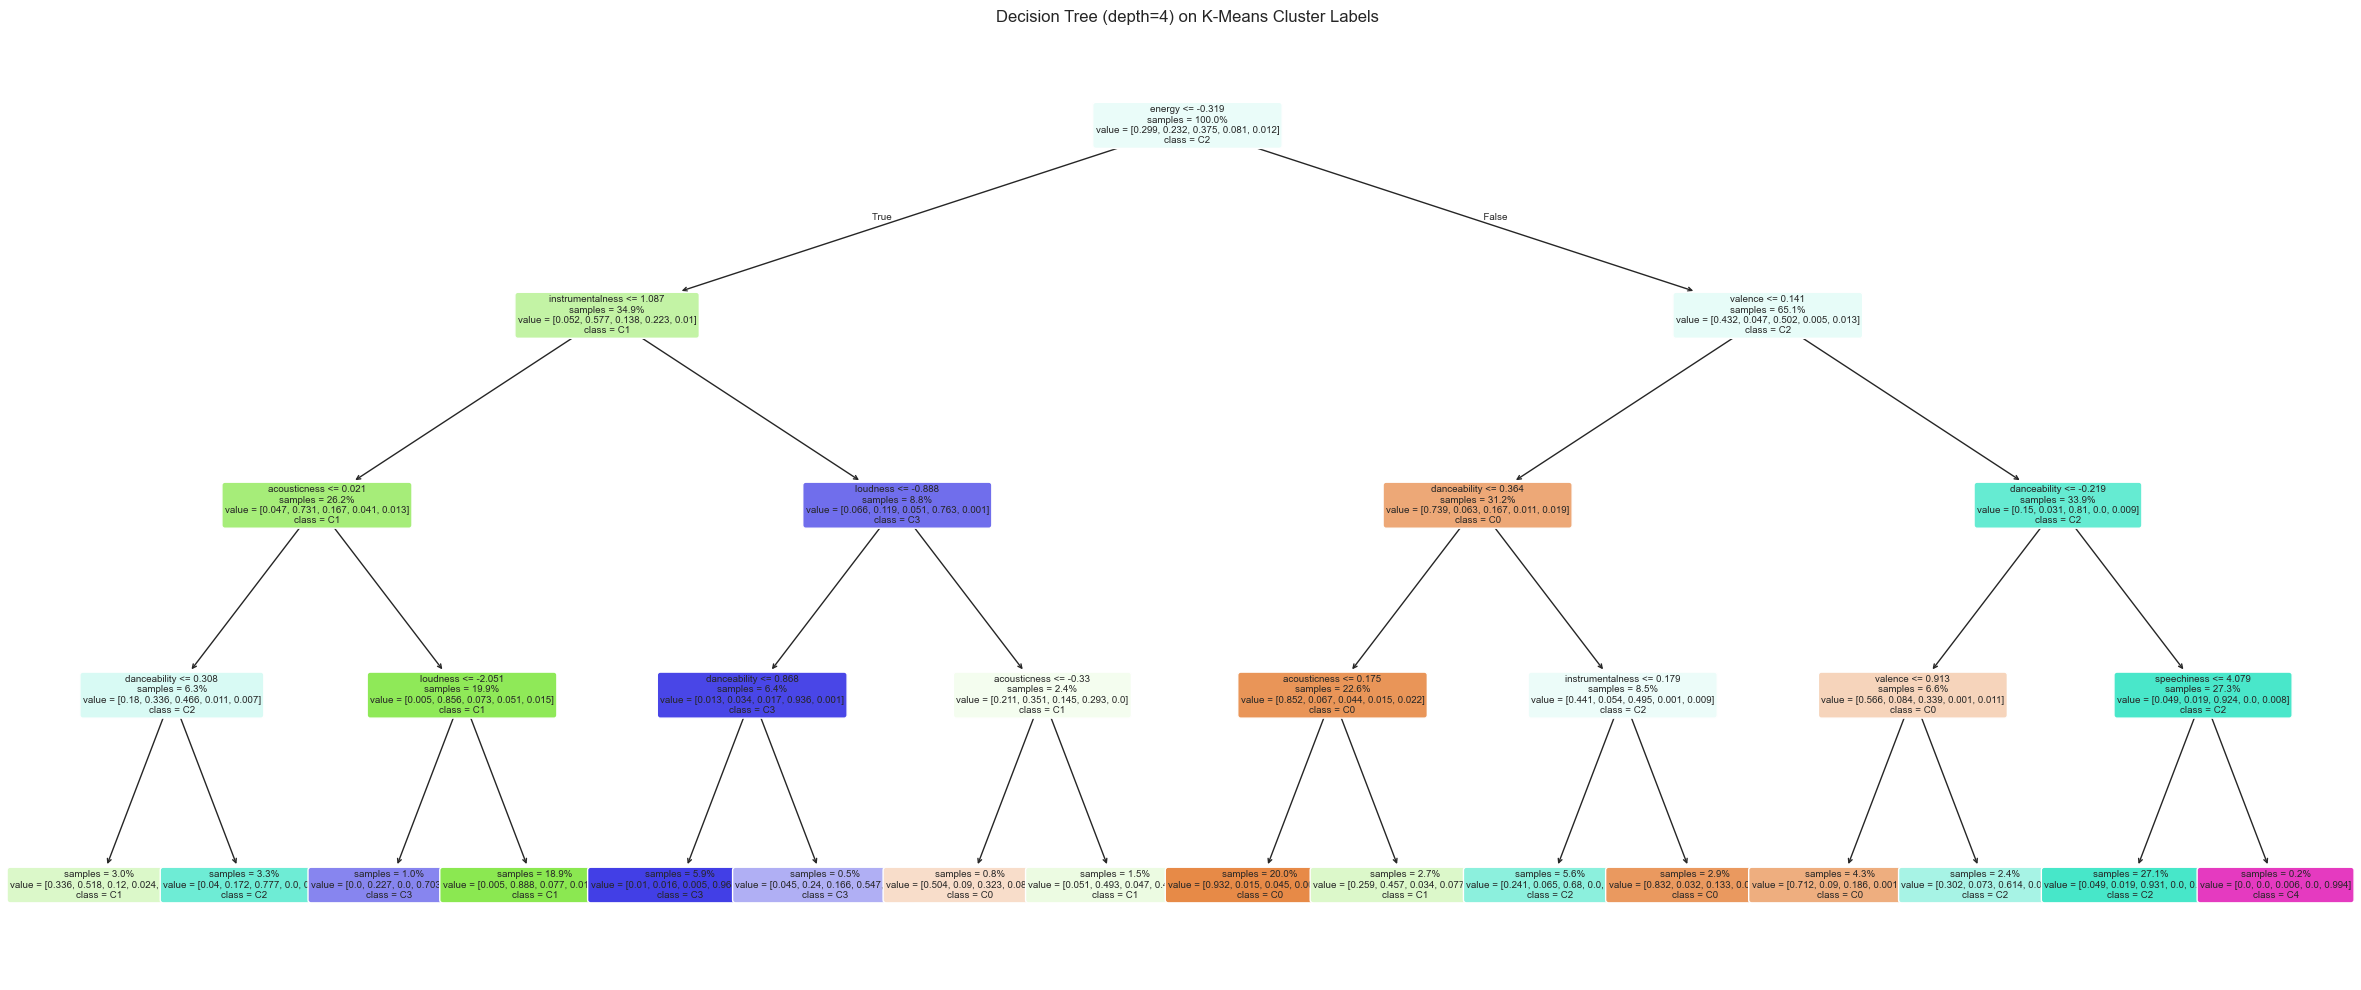

In [24]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(dt, feature_names=clustering_features, class_names=[f'C{i}' for i in range(5)],
          filled=True, rounded=True, ax=ax, fontsize=7, impurity=False, proportion=True)
ax.set_title('Decision Tree (depth=4) on K-Means Cluster Labels')
plt.tight_layout()
plt.savefig('../outputs/figures/fig17_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

the tree is readable at depth 4. you can trace any path from root to leaf and get a plain english rule for why a song lands in that cluster.

## 5. Anomaly Detection (LOF)

Using Local Outlier Factor to find songs that are unusual compared to their neighbors. Also comparing with the DBSCAN noise points from above.

In [25]:
np.random.seed(42)
lof_idx = np.random.choice(len(X_scaled), size=20000, replace=False)
X_lof = X_scaled[lof_idx]

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof_pred = lof.fit_predict(X_lof)

n_lof = (lof_pred == -1).sum()
print(f"LOF flagged {n_lof} anomalies out of 20k ({n_lof/len(X_lof)*100:.1f}%)")

LOF flagged 400 anomalies out of 20k (2.0%)


### what genres show up as anomalies?

In [26]:
lof_anom_idx = lof_idx[lof_pred == -1]
lof_df = df.iloc[lof_anom_idx]

print("top genres among LOF anomalies:")
print(lof_df['track_genre'].value_counts().head(10))

top genres among LOF anomalies:
track_genre
sleep             53
iranian           27
chill             17
classical         16
tango             11
children          10
study              9
funk               9
chicago-house      8
detroit-techno     8
Name: count, dtype: int64


In [27]:
print("\nfeature means -- anomalies vs overall:")
comp = pd.DataFrame({
    'anomalies': lof_df[clustering_features].mean(),
    'overall': df[clustering_features].mean()
})
comp['diff'] = comp['anomalies'] - comp['overall']
print(comp.round(3).to_string())


feature means -- anomalies vs overall:
                  anomalies  overall   diff
danceability          0.472    0.562 -0.091
energy                0.499    0.634 -0.135
valence               0.356    0.469 -0.114
acousticness          0.515    0.328  0.186
instrumentalness      0.365    0.173  0.191
speechiness           0.165    0.087  0.078
liveness              0.266    0.217  0.049
loudness            -14.392   -8.499 -5.893
tempo               113.734  122.058 -8.324


anomalies are quieter (loudness -14 vs -8.5), more acoustic, more instrumental, more speechy, and lower valence than average. basically they're the extremes -- either very quiet/ambient or very talky. sleep and iranian music show up a lot.

### LOF vs DBSCAN noise overlap

running LOF on the same 20k sample as DBSCAN to compare.

In [28]:
lof2 = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof2_pred = lof2.fit_predict(X_dbscan)
lof2_anom = lof2_pred == -1
db_noise = db_labels == -1

both = (lof2_anom & db_noise).sum()
print(f"DBSCAN noise: {db_noise.sum()}")
print(f"LOF anomalies: {lof2_anom.sum()}")
print(f"flagged by both: {both}")
print(f"\n~{both}/{db_noise.sum()} of DBSCAN noise also flagged by LOF ({both/db_noise.sum()*100:.0f}%)")

DBSCAN noise: 144
LOF anomalies: 400
flagged by both: 78

~78/144 of DBSCAN noise also flagged by LOF (54%)


about half the DBSCAN noise points are also LOF anomalies. LOF catches more because it uses local density rather than a global eps threshold. the overlap is reassuring though -- these are genuinely unusual songs.

### anomalies in PCA space

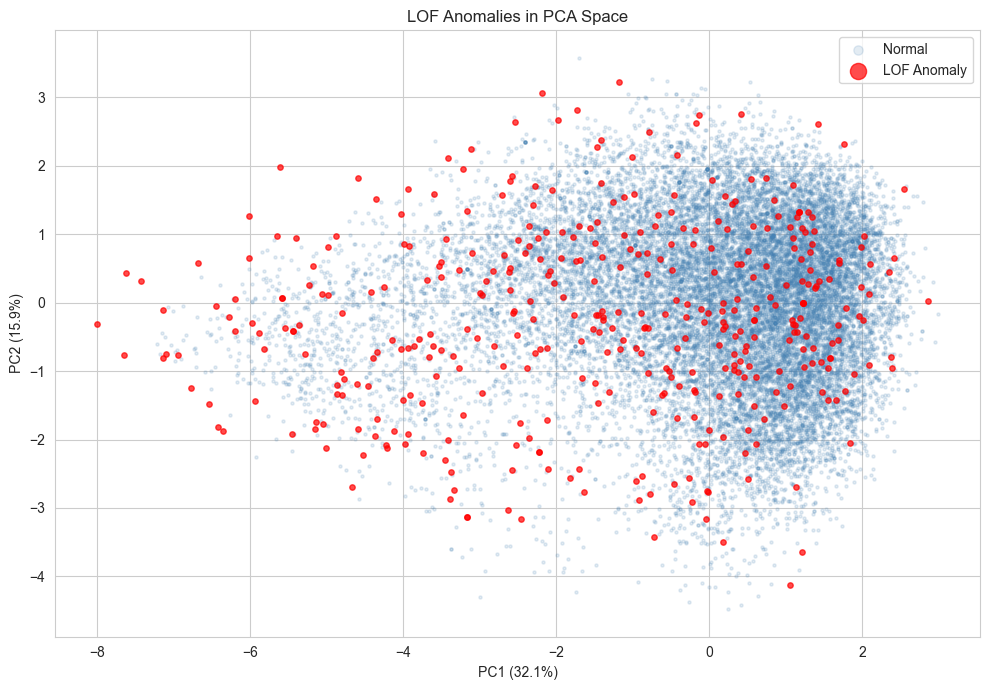

In [29]:
X_pca_lof = X_pca_all[lof_idx]

fig, ax = plt.subplots(figsize=(10, 7))
normal = lof_pred == 1
ax.scatter(X_pca_lof[normal, 0], X_pca_lof[normal, 1], c='steelblue', alpha=0.15, s=5, label='Normal')
ax.scatter(X_pca_lof[~normal, 0], X_pca_lof[~normal, 1], c='red', alpha=0.7, s=15, label='LOF Anomaly', zorder=5)
ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%})')
ax.set_title('LOF Anomalies in PCA Space')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../outputs/figures/fig18_lof_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

anomalies are scattered around the edges of the distribution, not clustered together. they're outliers in different ways -- some are extreme on PC1 (very acoustic or very loud), others on PC2 (very high or very low valence/danceability). there's no hidden "anomaly cluster."

### some actual anomalous tracks

In [30]:
print("sample anomalies:")
for _, row in lof_df.sample(10, random_state=42).iterrows():
    print(f"  {row['track_name']}")
    print(f"    {row['artists']} | {row['track_genre']}")
    print(f"    dance={row['danceability']:.2f} energy={row['energy']:.2f} loud={row['loudness']:.1f}dB speech={row['speechiness']:.2f} inst={row['instrumentalness']:.2f}")
    print()

sample anomalies:
  Massachusetts
    Bee Gees | disco
    dance=0.21 energy=0.46 loud=-13.4dB speech=0.05 inst=0.01

  The Nutcracker (Suite), Op. 71a, TH. 35: IIb. Dance of the Sugar-Plum Fairy
    Pyotr Ilyich Tchaikovsky;Berliner Philharmoniker;Mstislav Rostropovich | classical
    dance=0.28 energy=0.01 loud=-38.4dB speech=0.03 inst=0.00

  Crushed
    Actress | club
    dance=0.78 energy=0.63 loud=-10.9dB speech=0.27 inst=0.53

  Sleep Deeper
    Rain Sounds | sleep
    dance=0.27 energy=0.96 loud=-16.1dB speech=0.04 inst=0.00

  Halloween - Master Sound Productions 1980
    Misfits | hard-rock
    dance=0.42 energy=0.84 loud=-12.2dB speech=0.04 inst=0.14

  Alter Ego
    Ryuji Imaichi | j-dance
    dance=0.39 energy=0.71 loud=-7.7dB speech=0.21 inst=0.00

  The Music Of The Night - From 'The Phantom Of The Opera' Motion Picture
    Andrew Lloyd Webber;Gerard Butler | show-tunes
    dance=0.17 energy=0.07 loud=-19.2dB speech=0.04 inst=0.00

  It's Bigger Than Hip Hop UK Ft Dead P

## 6. Discovery Question Progress

**Primary: What natural clusters emerge, and how do they match genre labels?**

K-Means found 5 clusters with distinct audio profiles (M2). DBSCAN mostly sees one big cluster with a small speech-heavy offshoot, suggesting the 5-way split from K-Means is more about partitioning a continuous space than finding truly separated groups. genres don't map cleanly to clusters either way -- pop/electronic/dance overlap a lot, only classical and hip-hop are somewhat cluster-pure.

**Supporting 1: What latent dimensions underlie the features?**

Answered in M2 via PCA. PC1 = acoustic vs produced, PC2 = upbeat/danceable vs moody. confirmed again by the decision tree -- energy and valence are the two most important features for separating clusters.

**Supporting 2: What decision rules characterize each cluster?**

Answered in this notebook. The depth-4 tree gets ~85% accuracy and reveals clear rules: energy is the first split, then instrumentalness, acousticness, valence, and danceability. speechiness only matters for the hip-hop cluster. you can describe each cluster in plain english using 2-3 feature thresholds.

## 7. What's Left for the Final Report

- clean up visualizations for presentation quality
- write up a proper discussion of limitations (K-Means assumptions, DBSCAN sensitivity to eps, PCA losing information, etc.)
- maybe try broader genre groupings (rock/metal/punk as one family) for a cleaner genre-cluster comparison
- final report document

In [31]:
print(f"done. {len(df):,} tracks, {df['track_genre'].nunique()} genres")
print(f"techniques: K-Means (k=5), DBSCAN (eps=2.0), Decision Tree (depth=4), LOF")

done. 89,740 tracks, 113 genres
techniques: K-Means (k=5), DBSCAN (eps=2.0), Decision Tree (depth=4), LOF


---
## scratch work / experiments

In [32]:
# tried depth=3 tree first but it only got ~78% and missed cluster 4 entirely
# dt3 = DecisionTreeClassifier(max_depth=3, random_state=42)
# dt3.fit(X_scaled, df['cluster'])
# print(f"depth=3 accuracy: {dt3.score(X_scaled, df['cluster']):.4f}")
# depth=4 is the sweet spot -- deeper doesn't help much with interpretability

In [33]:
# tried LOF with contamination=0.05 but that flags way too many songs
# lof5 = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
# pred5 = lof5.fit_predict(X_lof)
# print(f"5% contamination: {(pred5 == -1).sum()} anomalies")
# 2% seems more reasonable

In [34]:
# TODO: for M4, try grouping the 113 genres into ~15 broader families
# genre_families = {
#     'rock': ['rock', 'alt-rock', 'hard-rock', 'psych-rock', 'punk-rock', 'rock-n-roll', 'grunge'],
#     'metal': ['metal', 'heavy-metal', 'death-metal', 'black-metal', 'metalcore', 'grindcore'],
#     'electronic': ['electronic', 'edm', 'house', 'deep-house', 'techno', 'trance', 'dubstep'],
# }
# might make the genre-cluster heatmap cleaner